In [353]:
using DataFrames
using CSV
using Plots
using Statistics
using StatsPlots
using HypothesisTests
using Clustering
using StatsBase
using Random



In [354]:
df = CSV.read("FASERIP.csv", DataFrame)
df.Health = df.F+df.A+df.S+df.E
df.Karma = df.R + df.I + df.P
first(df,5)

Row,character,F,A,S,E,R,I,P,Type,Flight,Armour,Ranged,Alignment,Health,Karma
,String31,Int64,Int64,Int64,Int64,Int64,Int64,Int64,String15,Int64,Int64,Int64,String7,Int64,Int64
1,Angel,20,30,10,30,10,6,10,Mutant,6,0,0,Hero,90,26
2,Aurora,20,20,6,20,4,10,4,Mutant,150,0,0,Hero,66,18
3,Beast,40,40,30,20,20,10,20,Mutant,0,0,0,Hero,130,50
4,Black Knight,30,20,10,10,10,6,6,Human,0,10,0,Hero,70,22
5,Box,30,30,75,75,20,10,10,Technological,40,50,0,Hero,210,40


In [355]:

# Assuming your FASERIP stat columns are already numerical and have names
# like :Fighting, :Agility, :Strength, :Endurance, :Reason, :Intuition, :Psyche.
# You might also have :Karma, depending on your dataset.
# Adjust this list to match the exact names of your FASERIP stat columns.
faserip_stat_columns = [:F, :A, :S, :E, :R, :I, :P]

# Calculate the mean for each FASERIP stat directly using `combine`
# The syntax `col => mean` means "apply the `mean` function to `col`"
average_stats = combine(df, faserip_stat_columns .=> mean)

println("Average FASERIP Stats:")
println(average_stats)


Average FASERIP Stats:
1×7 DataFrame
 Row │ F_mean   A_mean   S_mean   E_mean   R_mean   I_mean   P_mean  
     │ Float64  Float64  Float64  Float64  Float64  Float64  Float64 
─────┼───────────────────────────────────────────────────────────────
   1 │ 23.1951  24.1829  27.6463  39.3293  15.1707  19.6341  22.4878


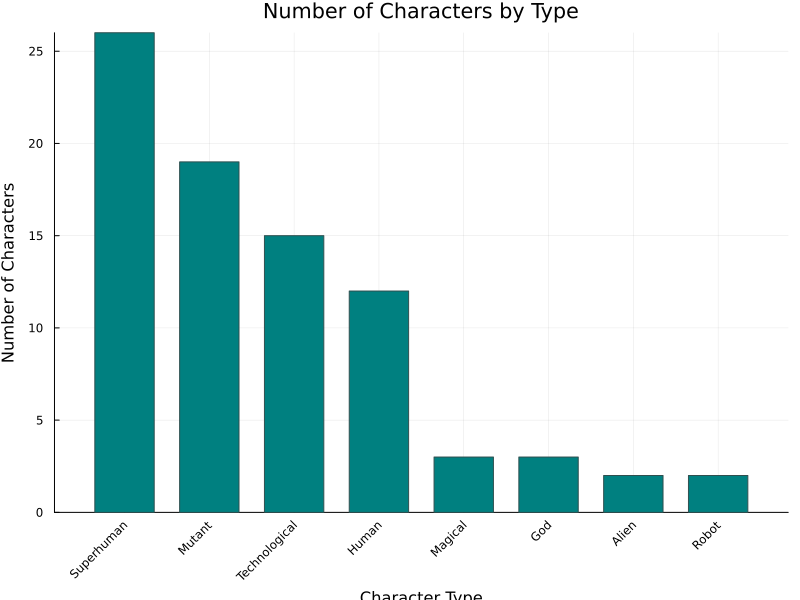

In [356]:
gr()
type_counts = combine(groupby(df, :Type), nrow => :Count)
sort!(type_counts, :Count, rev=true)

mygraph = bar(type_counts.Type, type_counts.Count,
    title="Number of Characters by Type",
    xlabel="Character Type",
    ylabel="Number of Characters",
    legend=false, # No legend needed for this type of plot
    bar_width=0.7, # Adjust bar width
    fillcolor=:teal, # Bar color
    linecolor=:darkslategray, # Bar border color
    xrotation=45, # Rotate x-axis labels if they are long
    size=(800, 600) # Set plot size (width, height)
)

savefig("character_type_bar_plot.png")
mygraph

Mean Strength by character type
8×2 DataFrame
 Row │ Type           MeanStrength 
     │ String15       Float64      
─────┼─────────────────────────────
   1 │ Mutant             14.8947
   2 │ Human              11.0
   3 │ Technological      33.0
   4 │ Superhuman         34.8077
   5 │ Magical             7.33333
   6 │ God                83.3333
   7 │ Alien              45.0
   8 │ Robot              45.0


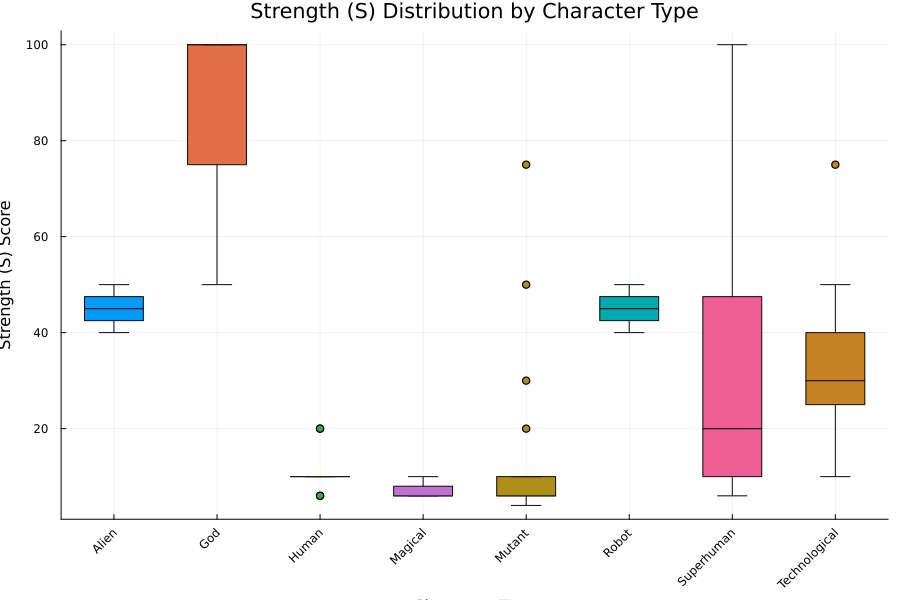

In [357]:
mean_strength_by_type = combine(groupby(df, :Type), :S => mean => :MeanStrength)

println("Mean Strength by character type")
println(mean_strength_by_type)

p_boxplot = boxplot(df.Type, df.S,
    group=df.Type, # This tells Plots.jl to group by the :Type column
    title="Strength (S) Distribution by Character Type",
    xlabel="Character Type",
    ylabel="Strength (S) Score",
    legend=false, # No legend needed for this
    xrotation=45, # Rotate x-axis labels if they are long
    size=(900, 600), # Adjust plot size
    # Optionally, you can add custom colors if desired
    # seriescolor = :Set2, # Or any other color palette
    # markeralpha = 0.6 # Transparency for outliers
)

p_boxplot



In [358]:
unique_types = unique(df.Type)
strength_by_type_groups = [df.S[df.Type .== t] for t in unique_types]
anova_result = OneWayANOVATest(strength_by_type_groups...) # The `...` "splats" the list into individual arguments
p_value = pvalue(anova_result)

println("\n--- One-Way ANOVA Results ---")
println("Comparing Mean Strength (S) across Character Types")
println("P-value: ", p_value)


--- One-Way ANOVA Results ---
Comparing Mean Strength (S) across Character Types
P-value: 4.688909750965954e-5


In [359]:
type_alignment_counts_long = combine(groupby(df, [:Type, :Alignment]), nrow => :Count)

println("--- Type vs. Alignment Counts (Long Format) ---")
println(type_alignment_counts_long)
println("\n")


type_alignment_pivot = unstack(type_alignment_counts_long, :Alignment, :Type, :Count)
println(type_alignment_pivot)


--- Type vs. Alignment Counts (Long Format) ---
15×3 DataFrame
 Row │ Type           Alignment  Count 
     │ String15       String7    Int64 
─────┼─────────────────────────────────
   1 │ Mutant         Hero          18
   2 │ Mutant         Villain        1
   3 │ Human          Hero           9
   4 │ Human          Villain        3
   5 │ Technological  Hero           4
   6 │ Technological  Villain       11
   7 │ Superhuman     Hero          19
   8 │ Superhuman     Villain        7
   9 │ Magical        Hero           2
  10 │ Magical        Villain        1
  11 │ God            Hero           2
  12 │ God            Villain        1
  13 │ Alien          Hero           1
  14 │ Alien          Villain        1
  15 │ Robot          Villain        2


2×9 DataFrame
 Row │ Alignment  Mutant  Human   Technological  Superhuman  Magical  God     Alien   Robot   
     │ String7    Int64?  Int64?  Int64?         Int64?      Int64?   Int64?  Int64?  Int64?  
─────┼────────────────────

In [360]:

type_alignment_counts_long = combine(groupby(df, [:Type, :Alignment]), nrow => :Count)
type_alignment_pivot_preferred = unstack(type_alignment_counts_long, :Type, :Alignment, :Count)

for col in names(type_alignment_pivot_preferred)
    # Check if column is numeric or union of Missing and Number before coalescing
    if eltype(type_alignment_pivot_preferred[!, col]) <: Union{Missing, Number}
        type_alignment_pivot_preferred[!, col] = coalesce.(type_alignment_pivot_preferred[!, col], 0)
    end
end

alignment_cols = names(type_alignment_pivot_preferred, Not(:Type))

observed_counts_matrix = Matrix(type_alignment_pivot_preferred[!, alignment_cols])

println("--- Observed Counts Matrix for Chi-Squared Test ---")
println(observed_counts_matrix)
println("\n")

chi_sq_test_result = ChisqTest(observed_counts_matrix)

# 3. Extract and interpret the P-value
p_value_chi2 = pvalue(chi_sq_test_result)

println("\n--- Chi-Squared Test of Independence Results ---")
println("Comparing independence of Character Type and Alignment")
println("P-value: ", p_value_chi2)


--- Observed Counts Matrix for Chi-Squared Test ---
[18 1; 9 3; 4 11; 19 7; 2 1; 2 1; 1 1; 0 2]



--- Chi-Squared Test of Independence Results ---
Comparing independence of Character Type and Alignment
P-value: 0.001863806163147302


In [362]:
Random.seed!(456)

faserip_cols_for_clustering = [:F, :A, :S, :E, :R, :I, :P, :Armour, :Ranged, :Flight]

X_raw = Matrix(df[!, faserip_cols_for_clustering]) # Get the selected columns as a matrix


X_scaled = similar(X_raw, Float64) # Create a new matrix of the same size, but Float64 type

for i in 1:size(X_raw, 2) # Iterate over columns (features)
    col = X_raw[:, i]
    col_mean = mean(col)
    col_std = std(col)
    X_scaled[:, i] = (col .- col_mean) ./ col_std # Apply standardization
end

println(X_scaled)

X_clust = X_scaled'
k=5

result = kmeans(X_clust, k; maxiter= 200, tol=1e-6)

println(counts(result))

df.Cluster = assignments(result)

println("\nFirst few rows with new Cluster assignments:")
# Display CharacterName, Type, and the new Cluster column, along with some key stats
select(df, :character, :Type, :F, :A, :S, :E, :R, :I, :P, :Health, :Karma, :Cluster) |> first
cluster_ids = sort(unique(df.Cluster))
for cluster_id in cluster_ids
    # Filter the DataFrame to get only the characters belonging to the current cluster
    characters_in_this_cluster = df[df.Cluster .== cluster_id, :]

    # Extract the character names from this filtered DataFrame
    names_list = characters_in_this_cluster.character

    # Print the cluster ID and the names within it
    println("\n--- Cluster $cluster_id (Total: $(length(names_list)) characters) ---")
    for name in names_list
        println("- $name")
    end
end


[-0.18424737444138928 0.39375612783999814 -0.6554259054453414 -0.40662223264471165 -0.43601553599655957 -0.8239097854130689 -0.613353687796964 -0.26946392419099163 -0.6690900851862551 -0.2001194976286417; -0.18424737444138928 -0.283141198845114 -0.8039951500798073 -0.8424787434534222 -0.9419580919170958 -0.5821902777069092 -0.9080509674806615 -0.26946392419099163 -0.6690900851862551 0.001519808455409953; 0.9690568014512764 1.0706534545251103 0.08742031772698755 -0.8424787434534222 0.4072220572043341 -0.5821902777069092 -0.12219155499080143 -0.26946392419099163 -0.6690900851862551 -0.20852113538214387; 0.39240471350494355 -0.283141198845114 -0.6554259054453414 -1.2783352542621327 -0.43601553599655957 -0.8239097854130689 -0.8098185409194291 -0.17931279492268762 -0.6690900851862551 -0.20852113538214387; 0.39240471350494355 0.39375612783999814 1.758824319864728 1.5547320659944859 0.4072220572043341 -0.5821902777069092 -0.613353687796964 0.18129172215052844 -0.6690900851862551 -0.1525102170